# GLM

- In this notebook we run GLM analysis for before and after button press periods for the MEI dataset

In [46]:
import nibabel as nib

from nilearn.input_data import NiftiMasker , MultiNiftiMasker, NiftiLabelsMasker
import nilearn as nil
import numpy as np 
import os
import os.path
import scipy.io
import nibabel as nib
import sys  
import random


from brainiak import image, io
from brainiak.io import load_boolean_mask
import brainiak.utils.fmrisim as sim  

from scipy.stats import stats
import nibabel as nib
import numpy as np
from matplotlib import pyplot as plt

import pandas as pd

#plot_roi(x)
from nilearn.image import concat_imgs, resample_img, mean_img
from nilearn.plotting import view_img
from nilearn import datasets, plotting
from nilearn.plotting import plot_glass_brain


from nilearn.glm.first_level import FirstLevelModel
from nilearn.glm.first_level import make_first_level_design_matrix
from nilearn.image import concat_imgs, resample_img, mean_img,index_img
from nilearn import image
from nilearn import masking
from nilearn.plotting import view_img
from nilearn.image import resample_to_img
from scipy.spatial.distance import squareform
# Visualize it as an ROI

from nilearn import image
from nilearn.image import math_img
from utils_anal import load_epi_data


random.seed(10)


# In[8]:



# Variables

### Directories 

In [47]:

top_dir = '/jukebox/graziano/coolCatIsaac/mei'
data_dir = top_dir + "/data"
work_dir = data_dir + '/work'
mask_dir = work_dir + '/masks'
behav_dir = top_dir + '/data/behavioral'
rois_dir = data_dir + "/rois"
fmri_prep = data_dir + '/bids/derivatives/fmriprep'
conf_dir = work_dir + '/confs'
preproc_dir = work_dir + '/glm_preproc'
fmri_glm_dir = work_dir + '/glm_data'
glm_sav_dir = work_dir + '/glm_out'

# Check if the directory exists, and create it if it doesn't
if not os.path.exists(glm_sav_dir):
    os.makedirs(glm_sav_dir)
    print(f"Directory created: {glm_sav_dir}")
    

### Sublist

In [65]:
'''
# sub-012
- Incorrect specification of additional regressors: length of regressors provided: 70, number of time-frames: 102
# sub-014
IndexError: list index out of range
'''


sub_list = [
    'sub-002', 'sub-003', 'sub-004', 'sub-005','sub-006','sub-007','sub-008','sub-009','sub-010',
    'sub-013','sub-014', 'sub-015', 'sub-016','sub-017','sub-018','sub-019','sub-020','sub-021',
    'sub-022','sub-023','sub-024','sub-025','sub-026','sub-027','sub-028', 'sub-029', 'sub-030','sub-031','sub-032',
    'sub-033','sub-034','sub-035','sub-036','sub-037','sub-038','sub-039','sub-040', 'sub-041'
]
sub_list = [
    'sub-002', 'sub-003', 'sub-004', 'sub-005','sub-006','sub-007','sub-008','sub-009','sub-010',
    'sub-013','sub-014'
]

#sub_list = ['sub-007']

# GLM 

In [49]:
fmri_glm = FirstLevelModel(t_r=1.5,
                           signal_scaling=False,
                           hrf_model = 'glover',
                           drift_order=None,
                           high_pass=None,
                           drift_model=None,
                           smoothing_fwhm=4,
                           standardize=True,
                           minimize_memory=False)

## other GLM vars
#comp_onset_list = [-3,0]
comp_onset_list = [0]
stim_dur = .01 # how long is the stimuous on

In [55]:
def create_event_list(bpress, comp_onset_list, stim_dur):
    """
    this function reads in a condition for each sub
    and returns the corresponding b4 + after events
    
    sub: subject number
    bpress: array of button press onset times
    cond: which condition do you want to create event dataframe fore
    """
    all_tims = []
    #events = {}
    events = []
    # Convert to array #
    bpress_arr = np.asarray(bpress)
    # Select runs to include according to run_dic, append
    #all_tims = all_tims + list(bpress_arr[run_dic[sub][cond]])
    # include all
    all_tims = bpress


    # events will take  the form of a dictionary of Dataframes, one per run! 
    for run in range(len(all_tims)):
        cond_labs = []
        duration = []
        onsets = []
        bpress_onsets = all_tims[run]
        # Do base first, then iterate on windows # 

        for idx, comp_onset in enumerate(comp_onset_list):
            # Create a list of 'press' for how many presses there were for each run
            
            # label evaluates to 'win1'
            cond_labs = cond_labs + ['win'+str(idx+1)]* len(all_tims[run])

            # How long does the button event event last? one tr, so 1.5
            duration = duration + [stim_dur] * len(all_tims[run])

            # these are the corresponding onset times
            onsets = onsets +  [y + comp_onset for y in bpress_onsets]
        # Define the events object
        events_ = pd.DataFrame(
            {'onset': onsets, 'trial_type': cond_labs, 'duration': duration})
        # remove the rest condition and insert into the dictionary
        #events[run_num+run] = events_
        events.append(events_)
    return events

In [37]:
sub_dic_behav = np.load(os.path.join(behav_dir, f'{sub}_behav.npy'), allow_pickle=True).item()
sub_dic_behav[key][mov_name][f'run-{str(run)}']['bpress']

[17.97337493102532,
 40.912360260030255,
 52.2944010279607,
 76.28736010799184,
 94.34045473893639,
 99.81345265801065,
 120.28236342698801,
 136.43037667998578,
 149.71939051395748]

In [45]:
start = sub_dic_behav[key]['cake'][f'run-{str(1)}']['start_tr']
end = sub_dic_behav[key]['cake'][f'run-{str(1)}']['end_tr']
start 

7

In [41]:
sub_dic_behav[key][mov_name][f'run-{str(run)}']['end_tr']

436

In [38]:
key

'Internal'

In [31]:
s_bpress[0]

26.787656157976016

### run

In [ ]:
sub_list = [
    'sub-002', 'sub-003', 'sub-004', 'sub-005','sub-006','sub-007','sub-008','sub-009','sub-010',
    'sub-013'
]

In [72]:
sub_list

['sub-002',
 'sub-003',
 'sub-004',
 'sub-005',
 'sub-006',
 'sub-007',
 'sub-008',
 'sub-009',
 'sub-010',
 'sub-013',
 'sub-014']

In [78]:
cond_list = ['internal']
s_glm_out = {}
movie_list = ['office']
target_run = 1



for sub in sub_list:
    print(f'* STARTING {sub} *')
    s_dat = np.load(f'{fmri_glm_dir}/{sub}_bpress_fmri_data.npy', allow_pickle=True).item()
    break_ = False
    movie_list = list(s_dat[cond].keys())
    
    for cond in cond_list:
        events_across_mov = []
        bold_across_mov = []
        c_across_mov = []
        frame_times = []
        for m in movie_list: # get movie names. not necessary to know which movies
            print(f'movie {m} with')

            if m not in s_dat[cond]:
                break_ = True
                print('NONE')
                continue
                
            # get bpresses
            s_bpress = s_dat[cond][m]['b']
            if len(s_bpress) == 0: continue ## skip if no data... this is weird tho
            print(f'Num bpress: {len(s_bpress)}')

            events = create_event_list(s_bpress, comp_onset_list,stim_dur)
            #print(events)
            #events_across_mov.update(events) # merge dictionaries across movie
            events_across_mov = events_across_mov + events
            #print(f'\nBOLD', len(s_dat[cond][m]['f']))

            # get fMRI
            bold_across_mov = bold_across_mov + s_dat[cond][m]['f'] # add to existing
            print(f'Num fMRI: {len(bold_across_mov)}')
            # confounds
            c_across_mov = c_across_mov + s_dat[cond][m]['c'] # add to existing
            # frametimes
            f_tem1 = [s_dat[cond][m]['f'][0].shape[3]] * len(s_dat[cond][m]['f'])
            f_tem2 =[np.arange(i) * 1.5 for i in f_tem1]
            frame_times = frame_times + f_tem2
            #print(f'frametimes: {frame_times}')
            
        if break_: continue
        events_across_mov_d = {idx: ev for idx, ev in enumerate(events_across_mov)}

            
        # Create design matrix - SM
        #design_matrices = [make_first_level_design_matrix(frame_times[df], events_across_mov_d[df], hrf_model = 'glover',
                   #   drift_model=None, add_regs=c_across_mov[df]) for df in events_across_mov_d]
        design_matrices = [make_first_level_design_matrix(frame_times[df], events_across_mov_d[df], hrf_model = 'glover',
                      drift_model=None) for df in events_across_mov_d]
        
        
        ## Run GLM ##
        window_list = ['win1']
        s_glm_win = {}
        for win in window_list:
            
            print(f'processing {sub} {cond} {win}')
            # group sub glm is now a nested dictionary with three contrasts
            ## COND A ## 
            fmri_glm = fmri_glm.fit(bold_across_mov, design_matrices=design_matrices) 
            # Compute contrasts #
            beta_map = fmri_glm.compute_contrast(
                    win, output_type='effect_size') #effect_size
            
            # Save INDIVIDUAL WITHIN CONTRASTS
            s_glm_win[win] = beta_map 
            nib.save(beta_map, os.path.join(glm_sav_dir, '%s_%s_%s_bmap.nii') %(sub, cond, win))


            print('finish',win)
        s_glm_out[sub] = s_glm_win
        print('finish', sub)
            
        
    

* STARTING sub-002 *
movie office with
NONE
* STARTING sub-003 *
movie office with
Num bpress: 4
Num fMRI: 4
processing sub-003 internal win1


/jukebox/pkgs/PYGER/base/envs/0.11.0/lib/python3.7/site-packages/nilearn/glm/first_level/first_level.py:576: UserWarning: One contrast given, assuming it for all 4 runs
  warn('One contrast given, assuming it for all %d runs' % n_runs)


finish win1
finish sub-003
* STARTING sub-004 *
movie office with
Num bpress: 4
Num fMRI: 4
processing sub-004 internal win1
finish win1
finish sub-004
* STARTING sub-005 *
movie office with
NONE
* STARTING sub-006 *
movie office with
NONE
* STARTING sub-007 *
movie office with
Num bpress: 4
Num fMRI: 4
processing sub-007 internal win1
finish win1
finish sub-007
* STARTING sub-008 *
movie office with
Num bpress: 3
Num fMRI: 3
processing sub-008 internal win1


/jukebox/pkgs/PYGER/base/envs/0.11.0/lib/python3.7/site-packages/nilearn/glm/first_level/first_level.py:576: UserWarning: One contrast given, assuming it for all 3 runs
  warn('One contrast given, assuming it for all %d runs' % n_runs)


finish win1
finish sub-008
* STARTING sub-009 *
movie office with
NONE
* STARTING sub-010 *
movie office with
NONE
* STARTING sub-013 *
movie office with
NONE
* STARTING sub-014 *
movie office with
NONE


In [74]:
list(s_glm_out.keys())

['sub-003', 'sub-004', 'sub-007', 'sub-008']

In [60]:
events_across_mov_d[0]

,onset,trial_type,duration
0,20.895418,win1,0.01
1,42.921368,win1,0.01
2,54.254353,win1,0.01
3,57.179388,win1,0.01
4,74.289353,win1,0.01
5,94.672411,win1,0.01
6,113.214344,win1,0.01
7,135.736377,win1,0.01
8,147.883240,win1,0.01


In [62]:
bold_across_mov[0]

## Two runs office internal

/jukebox/pkgs/PYGER/base/envs/0.11.0/lib/python3.7/site-packages/ipykernel_launcher.py:48: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


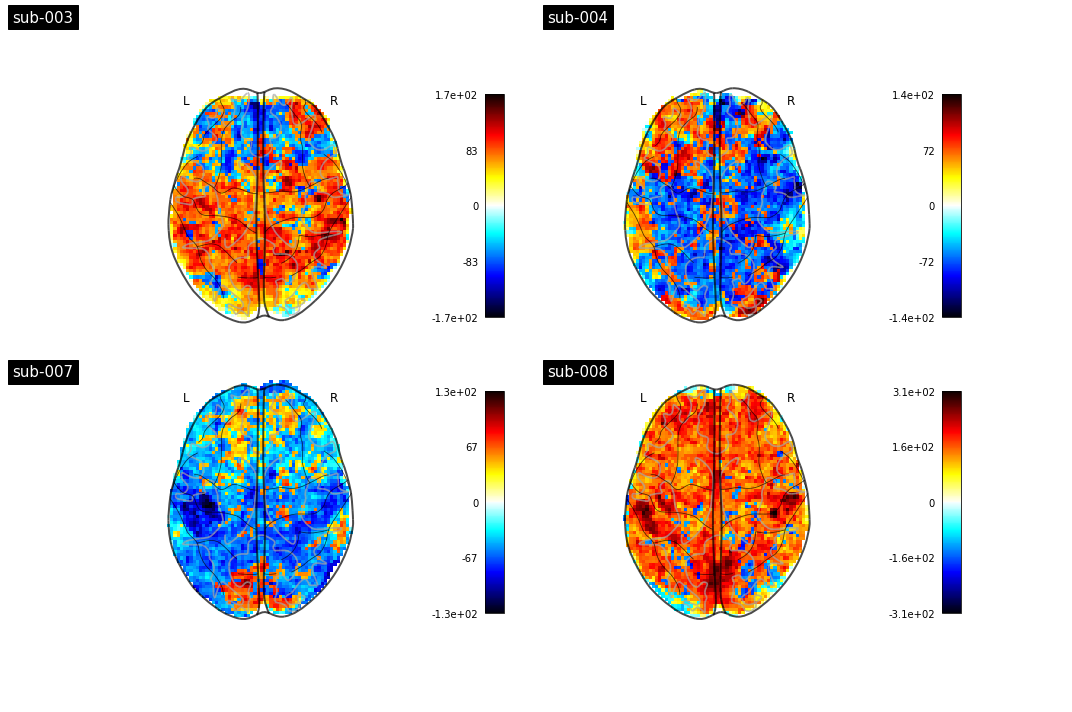

In [77]:
# Assuming `s_glm_out` is a dictionary with NIfTI-like images as values
# and the keys are the names of the corresponding maps.
num_keys = len(s_glm_out.keys())
keys = list(s_glm_out.keys())

# Determine subplot grid dimensions
rows = int(num_keys ** 0.5)
cols = (num_keys + rows - 1) // rows  # Ensure enough columns for all plots

# Create a figure for the subplots
fig, axes = plt.subplots(rows, cols, figsize=(15, 10))

# Flatten axes for easy indexing
axes = axes.flatten()

left_premotor_coords = (-40, -20, 60)


# Plot each stat map
for i, key in enumerate(list(s_glm_out.keys())):
    ax = axes[i]
    # Plot the stat map corresponding to the current key
    '''
    plot_stat_map(
        s_glm_out[key]['win1'],
        axes=ax,
        title=key,
        cut_coords=left_premotor_coords,
        colorbar=True,
        display_mode='ortho'  # Adjust to your preferred display mode
    )
    '''
    # Plot the glass brain corresponding to the current key
    display = plot_glass_brain(
        s_glm_out[key]['win1'],
        axes=ax,
        title=key,
        colorbar=True,
        display_mode='z',  # Axial view only
        plot_abs=False  # Set to True if absolute values are preferred
    )
    
# Hide any unused subplots if keys are fewer than subplots
for j in range(len(keys), len(axes)):
    axes[j].axis('off')

# Adjust layout
plt.tight_layout()
plt.show()


## Four runs office internal

/jukebox/pkgs/PYGER/base/envs/0.11.0/lib/python3.7/site-packages/ipykernel_launcher.py:48: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


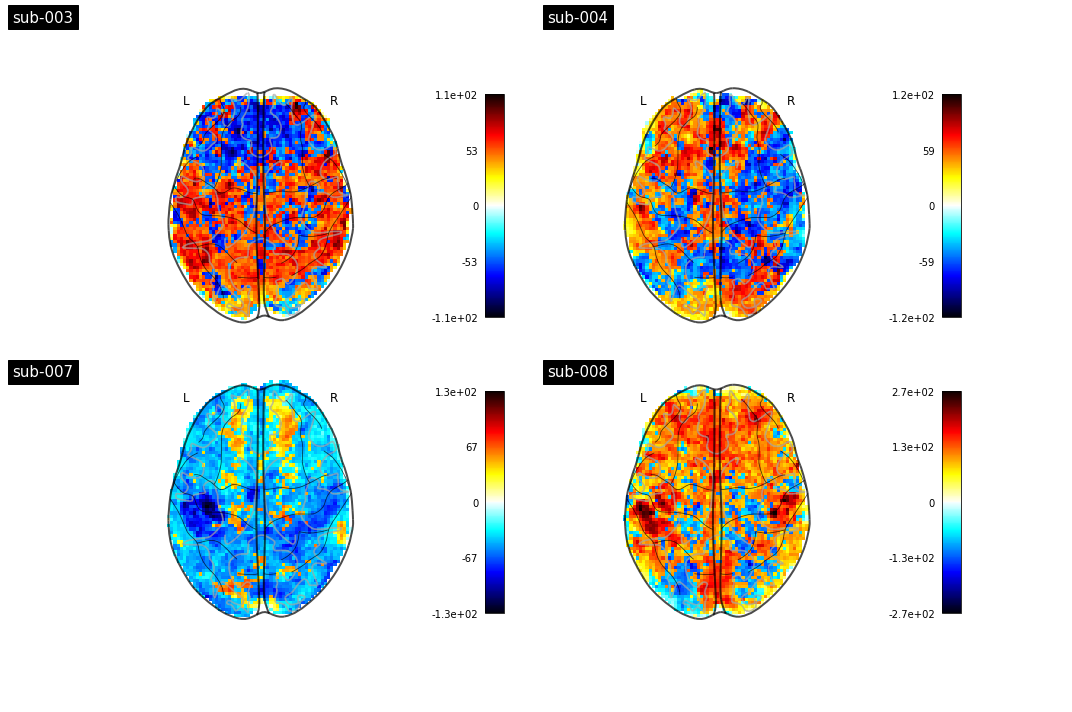

In [79]:
# Assuming `s_glm_out` is a dictionary with NIfTI-like images as values
# and the keys are the names of the corresponding maps.
num_keys = len(s_glm_out.keys())
keys = list(s_glm_out.keys())

# Determine subplot grid dimensions
rows = int(num_keys ** 0.5)
cols = (num_keys + rows - 1) // rows  # Ensure enough columns for all plots

# Create a figure for the subplots
fig, axes = plt.subplots(rows, cols, figsize=(15, 10))

# Flatten axes for easy indexing
axes = axes.flatten()

left_premotor_coords = (-40, -20, 60)


# Plot each stat map
for i, key in enumerate(list(s_glm_out.keys())):
    ax = axes[i]
    # Plot the stat map corresponding to the current key
    '''
    plot_stat_map(
        s_glm_out[key]['win1'],
        axes=ax,
        title=key,
        cut_coords=left_premotor_coords,
        colorbar=True,
        display_mode='ortho'  # Adjust to your preferred display mode
    )
    '''
    # Plot the glass brain corresponding to the current key
    display = plot_glass_brain(
        s_glm_out[key]['win1'],
        axes=ax,
        title=key,
        colorbar=True,
        display_mode='z',  # Axial view only
        plot_abs=False  # Set to True if absolute values are preferred
    )
    
# Hide any unused subplots if keys are fewer than subplots
for j in range(len(keys), len(axes)):
    axes[j].axis('off')

# Adjust layout
plt.tight_layout()
plt.show()


## no regressors 

/jukebox/pkgs/PYGER/base/envs/0.11.0/lib/python3.7/site-packages/ipykernel_launcher.py:50: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


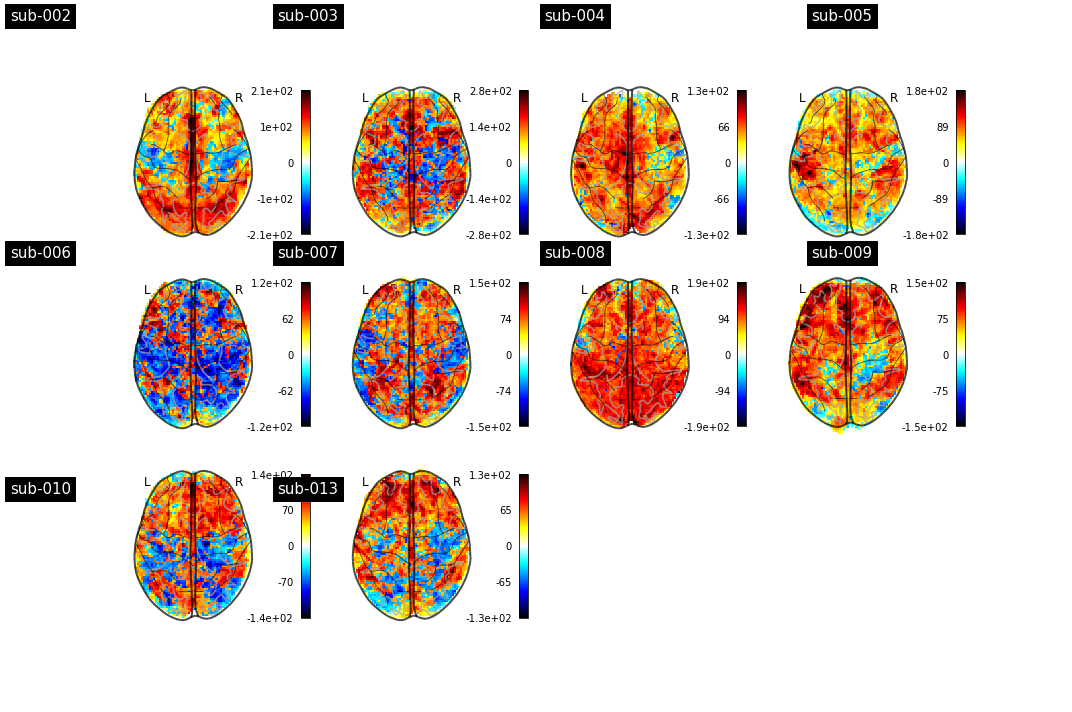

In [367]:
# Assuming `s_glm_out` is a dictionary with NIfTI-like images as values
# and the keys are the names of the corresponding maps.
num_keys = len(s_glm_out.keys())
keys = list(s_glm_out.keys())

# Determine subplot grid dimensions
rows = int(num_keys ** 0.5)
cols = (num_keys + rows - 1) // rows  # Ensure enough columns for all plots

# Create a figure for the subplots
fig, axes = plt.subplots(rows, cols, figsize=(15, 10))

# Flatten axes for easy indexing
axes = axes.flatten()

left_premotor_coords = (-40, -20, 60)


# Plot each stat map
for i, key in enumerate(list(s_glm_out.keys())):
    ax = axes[i]
    # Plot the stat map corresponding to the current key
    '''
    plot_stat_map(
        s_glm_out[key]['win1'],
        axes=ax,
        title=key,
        cut_coords=left_premotor_coords,
        colorbar=True,
        display_mode='ortho'  # Adjust to your preferred display mode
    )
    '''
    # Plot the glass brain corresponding to the current key
    display = plot_glass_brain(
        s_glm_out[key]['win1'],
        axes=ax,
        title=key,
        colorbar=True,
        display_mode='z',  # Axial view only
        plot_abs=False  # Set to True if absolute values are preferred
    )
    
# Hide any unused subplots if keys are fewer than subplots
for j in range(len(keys), len(axes)):
    axes[j].axis('off')

# Adjust layout
plt.tight_layout()
plt.show()


## regressors in glm

/jukebox/pkgs/PYGER/base/envs/0.11.0/lib/python3.7/site-packages/ipykernel_launcher.py:37: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


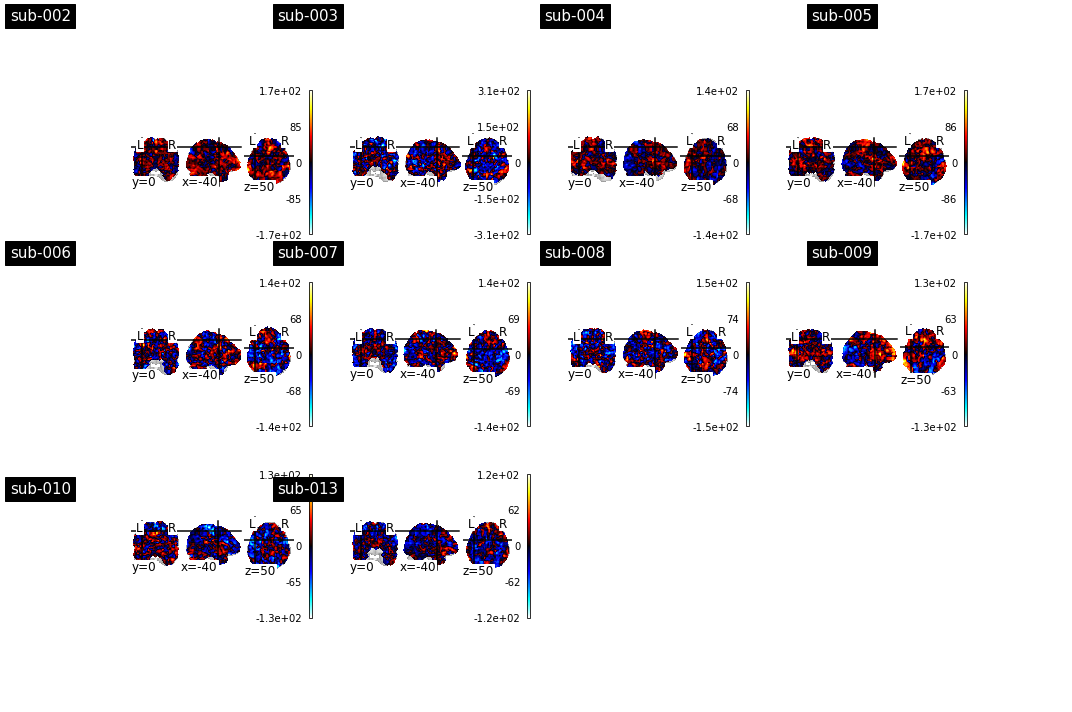

In [360]:
# Assuming `s_glm_out` is a dictionary with NIfTI-like images as values
# and the keys are the names of the corresponding maps.
num_keys = len(s_glm_out.keys())
keys = list(s_glm_out.keys())

# Determine subplot grid dimensions
rows = int(num_keys ** 0.5)
cols = (num_keys + rows - 1) // rows  # Ensure enough columns for all plots

# Create a figure for the subplots
fig, axes = plt.subplots(rows, cols, figsize=(15, 10))

# Flatten axes for easy indexing
axes = axes.flatten()

left_premotor_coords = (-40, 0, 50)


# Plot each stat map
for i, key in enumerate(list(s_glm_out.keys())):
    ax = axes[i]
    # Plot the stat map corresponding to the current key
    plot_stat_map(
        s_glm_out[key]['win1'],
        axes=ax,
        title=key,
        cut_coords=left_premotor_coords,
        colorbar=True,
        display_mode='ortho'  # Adjust to your preferred display mode
    )

# Hide any unused subplots if keys are fewer than subplots
for j in range(len(keys), len(axes)):
    axes[j].axis('off')

# Adjust layout
plt.tight_layout()
plt.show()


In [220]:
events_across_mov_x = [i for i in events_across_mov]
len(events_across_mov_x)

3

In [ ]:
''' NOTES 
did we discard runs with no button presses correctly

'''